In [1]:
import json
import re
import matplotlib.pyplot as plt
import numpy as np
import ast

In [58]:
with open("llama_70b_negoeval_without_backfilling.json", "r") as f:
    llama_70b = json.load(f)

with open("llama_8b_negoeval_without_backfilling.json", "r") as f:
    llama_8b = json.load(f)

with open('intent_human_dialogue_negoeval.jsonl', 'r') as f:
    intent_human_dialogue = [json.loads(line) for line in f]

with open('intent_human_dialogue.json', 'r') as f:
    actual = json.load(f)
countries_list = ['Austria', 'England', 'France', 'Germany', 'Italy', 'Russia', 'Turkey']

In [60]:
def dialogue_count(data):
    return len(data['intent_dialogue'].split('\n')) if data['intent_dialogue'] != "" else 0
    
def get_score_with_env(countries, prediction):
    scores = 0
    for c in countries:
        scores += prediction[c][c.upper()][1]
    score_dict = {}
    score_dict['env'] = prediction['env_uuid']
    score_dict['scores'] = scores / len(countries)
    score_dict['dialogue_count'] = dialogue_count(prediction)
    return score_dict

def get_score_dict_from_dialogue(dialogue):
    score_list = []
    empty_predict_count = 0
    
    for item in dialogue:
        if item['intent_dialogue'] == "":
            continue
        
        # 找出所有国家键
        country_keys = [k for k in item.keys() if k in countries_list]
        
        # 过滤掉 '{country}_original_predict' 为空的情况
        valid_countries = []
        for country in country_keys:
            predict_key = f"{country}_original_predict"
            if predict_key in item and item[predict_key] != "":
                valid_countries.append(country)
            else:
                empty_predict_count += 1
        
        # 如果没有有效的国家，则跳过此条记录
        if len(valid_countries) != 2:
            continue
        
        score_list.append(get_score_with_env(valid_countries, item))
    
    return score_list

def average_dialogue_count(score_list):
    dialogue_count = 0
    for i in score_list:
        dialogue_count += i['dialogue_count']
    return dialogue_count / len(score_list)

def plot_correlation_of_score_and_dialogue_count(data, title):

    # 提取 scores 和 dialogue_count
    scores = np.array([item['scores'] for item in data])
    dialogue_counts = np.array([item['dialogue_count'] for item in data])

    # 设置 Seaborn 主题
    sns.set_theme(style="whitegrid")  # 可选 "whitegrid", "darkgrid", "white", "dark" 等

    plt.figure(figsize=(8, 6))

    # 绘制散点图：加一些透明度 (alpha) 和边框 (edgecolors)
    plt.scatter(
        dialogue_counts, 
        scores, 
        color='royalblue', 
        alpha=0.8, 
        edgecolors='black', 
        s=100,  # 调整散点大小
        label='Data points'
    )

    # 线性回归拟合（一次多项式）
    coefficients = np.polyfit(dialogue_counts, scores, 1)
    polynomial = np.poly1d(coefficients)

    # 生成拟合曲线
    x_line = np.linspace(dialogue_counts.min(), dialogue_counts.max(), 100)
    y_line = polynomial(x_line)
    plt.plot(x_line, y_line, color='red', linewidth=2, label='Fit line')

    # 坐标轴、标题、图例
    plt.xlabel('Dialogue Count', fontsize=12)
    plt.ylabel('Scores', fontsize=12)
    plt.title(title, fontsize=12, fontweight='bold')
    plt.legend()

    # 显示图表
    plt.show()

In [4]:

llama_70b_score_dict = get_score_dict_from_dialogue(llama_70b)
llama_8b_score_dict = get_score_dict_from_dialogue(llama_8b)
intent_human_score_dict = get_score_dict_from_dialogue(intent_human_dialogue)
llama_70b_average_dialogue_count = average_dialogue_count(llama_70b_score_dict)
llama_8b_average_dialogue_count = average_dialogue_count(llama_8b_score_dict)
intent_human_average_dialogue_count = average_dialogue_count(intent_human_score_dict)actual_score_dict = get_score_dict_from_dialogue(actual)

In [5]:
len(llama_70b_score_dict), len(llama_8b_score_dict),len(intent_human_score_dict), len(llama_70b), len(llama_8b), len(intent_human_dialogue)

(283, 277, 257, 493, 495, 257)

In [6]:
def match_env_ids(score_dict1, score_dict2, score_dict3):
    env_ids1 = {item['env'] for item in score_dict1}
    env_ids2 = {item['env'] for item in score_dict2}
    env_ids3 = {item['env'] for item in score_dict3}
    
    common_env_ids = env_ids1 & env_ids2 & env_ids3
    
    def filter_by_env_ids(score_dict, env_ids):
        return [item for item in score_dict if item['env'] in env_ids]
    
    filtered_score_dict1 = filter_by_env_ids(score_dict1, common_env_ids)
    filtered_score_dict2 = filter_by_env_ids(score_dict2, common_env_ids)
    filtered_score_dict3 = filter_by_env_ids(score_dict3, common_env_ids)
    
    return filtered_score_dict1, filtered_score_dict2, filtered_score_dict3

llama_70b_matched, llama_8b_matched, intent_human_matched = match_env_ids(llama_70b_score_dict, llama_8b_score_dict, intent_human_score_dict)


In [7]:
len(llama_70b_matched), len(llama_8b_matched), len(intent_human_matched)

(257, 257, 257)

In [28]:
match_env_ids = [i['env'] for i in llama_70b_matched]

/tmp/ipykernel_1706671/2173471177.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=labels, y=values, palette="Blues_r")


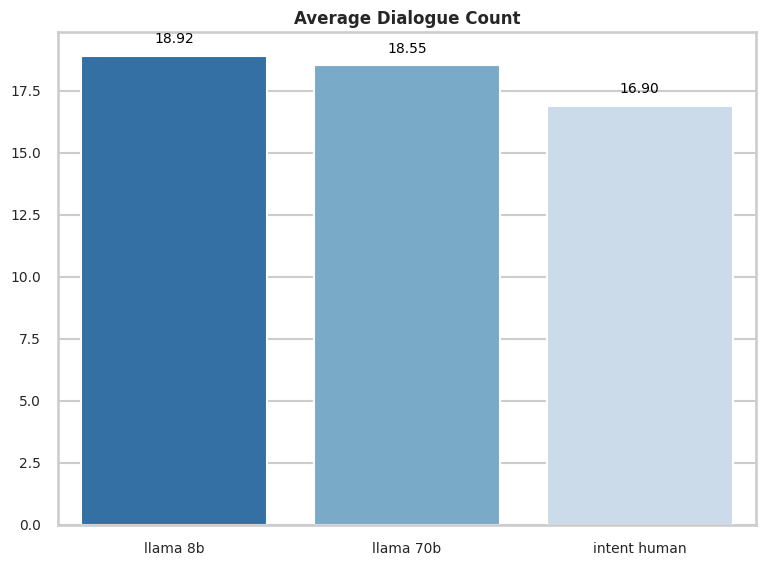

In [8]:
# Average dialogue count plot

import matplotlib.pyplot as plt
import seaborn as sns

values = [llama_8b_average_dialogue_count, llama_70b_average_dialogue_count, intent_human_average_dialogue_count]

labels = ["llama 8b", "llama 70b", "intent human"]

sns.set_style("whitegrid")  
sns.set_context("talk")

plt.figure(figsize=(8, 6))

ax = sns.barplot(x=labels, y=values, palette="Blues_r")

for i, v in enumerate(values):
    ax.text(i, v + 0.5, f"{v:.2f}", 
            horizontalalignment='center', 
            color='black', 
            fontsize=10)

plt.title("Average Dialogue Count", fontsize=12, fontweight='bold')
# plt.xlabel("Model", fontsize=12)
# plt.ylabel("Count", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.tight_layout()

plt.show()


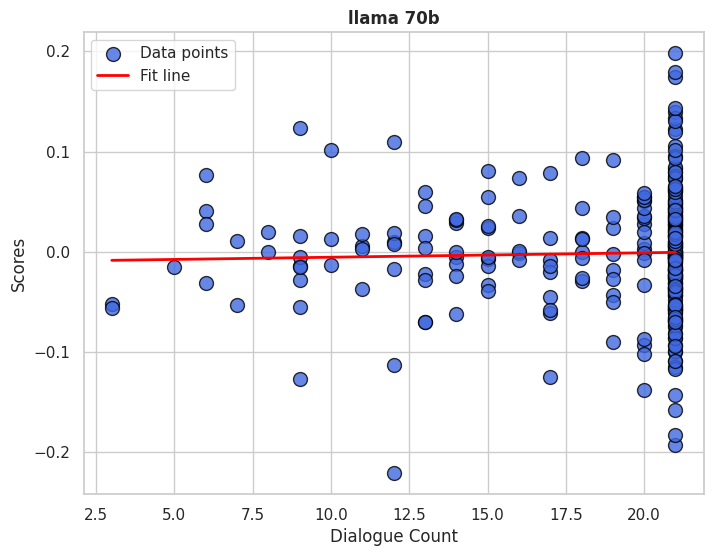

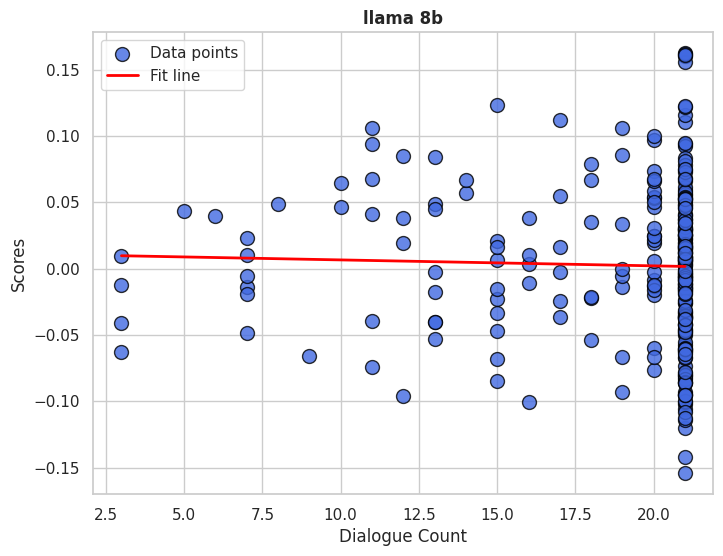

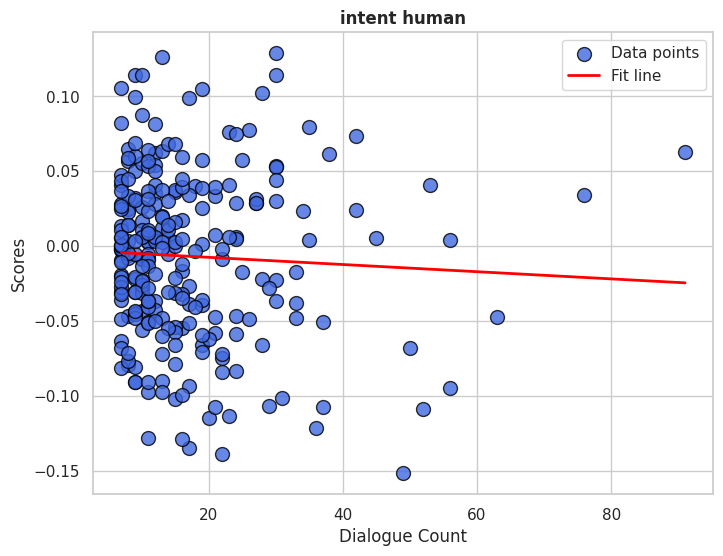

In [9]:
plot_correlation_of_score_and_dialogue_count(llama_70b_score_dict, "llama 70b")
plot_correlation_of_score_and_dialogue_count(llama_8b_score_dict, "llama 8b")
plot_correlation_of_score_and_dialogue_count(intent_human_score_dict, "intent human")

In [10]:
def compute_overlap(actual, predicted):
    """
    计算两个列表的重合度，采用 Jaccard 指数：交集大小 / 并集大小。
    若两者都为空，则认为重合度为 1.
    """
    actual_set = set(actual) if actual else set()
    predicted_set = set(predicted) if predicted else set()
    
    # 如果两者都为空，则认为完全重合
    if not actual_set and not predicted_set:
        return 1.0
    # 如果只有其中一个为空，则重合度为 0
    if not actual_set or not predicted_set:
        return 0.0
    
    intersection = actual_set.intersection(predicted_set)
    union = actual_set.union(predicted_set)
    return len(intersection) / len(union)

def average_overlap_parse_actual(data_list, countries_list):
    overlap_scores = []
    empty_predict_count = 0
    
    for item in data_list:
        if item['intent_dialogue'] == "":
            continue
        
        # 过滤掉 original_predict 为空的情况
        country_keys = [k for k in item.keys() if k in countries_list]
        
        # 过滤掉 '{country}_original_predict' 为空的情况
        valid_countries = []
        for country in country_keys:
            predict_key = f"{country}_original_predict"
            if predict_key in item and item[predict_key] != "":
                valid_countries.append(country)
            else:
                empty_predict_count += 1
        
        # 如果没有有效的国家，则跳过此条记录
        if len(valid_countries) != 2:
            continue
            
        # 对每个有效的国家计算重合度
        for country in valid_countries:
            actual_key = f"{country}_actual_movement"
            predict_key = f"{country}_parse_predict"
            
            if actual_key in item and predict_key in item:
                actual_moves = item[actual_key] or []
                predicted_moves = item[predict_key] or []
                score = compute_overlap(actual_moves, predicted_moves)
                overlap_scores.append({
                    'env_uuid': item.get('env_uuid'),
                    'score': score
                })
    
    return overlap_scores
    
def average_overlap_parse_predict(data_list, countries_list):
    overlap_scores = []
    for data in data_list:
        if data['intent_dialogue'] == "":
            continue
        for country in countries_list:
            origin_predict_key = f"{country}_original_predict"
            predict_key = f"{country}_parse_predict"
            if origin_predict_key in data and predict_key in data:
                if data.get(origin_predict_key) == "":
                    continue
                origin_predict_moves = data[origin_predict_key] or ""
                origin_predict_moves = [move.strip() for move in origin_predict_moves.split(';') if move.strip()]
                predicted_moves = data[predict_key] or []
                score = compute_overlap(origin_predict_moves, predicted_moves)
                overlap_scores.append({
                    'env_uuid': data.get('env_uuid'),
                    'score': score
                })
    return overlap_scores

In [11]:
llama_70b_average_overlap = average_overlap_parse_actual(llama_70b, countries_list)
llama_8b_average_overlap = average_overlap_parse_actual(llama_8b, countries_list)
intent_human_average_overlap = average_overlap_parse_actual(intent_human_dialogue, countries_list)
parse_predict_llama_8b_average_overlap = average_overlap_parse_predict(llama_8b, countries_list)
parse_predict_llama_70b_average_overlap = average_overlap_parse_predict(llama_70b, countries_list)
parse_predict_intent_human_average_overlap = average_overlap_parse_predict(intent_human_dialogue, countries_list)

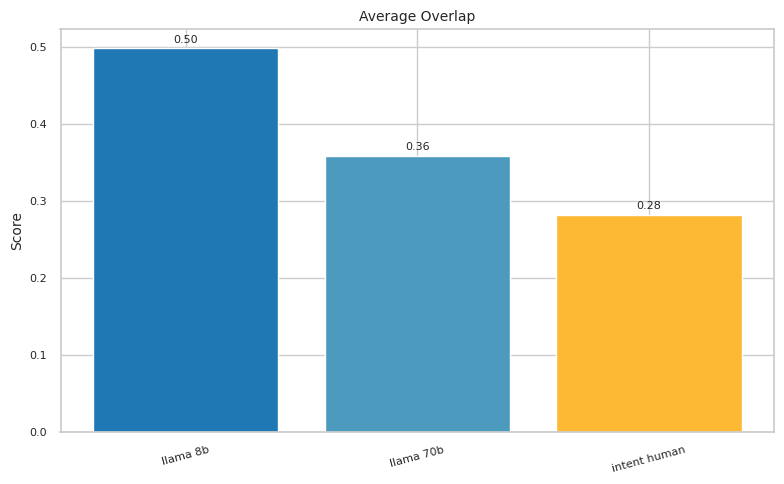

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# 数据
labels = ['llama 8b', 
          'llama 70b',
          'intent human']

# 计算每个列表中的平均分数
def calculate_average_score(score_list):
    scores = [item['score'] for item in score_list]
    return np.mean(scores) if scores else 0

values = [
    calculate_average_score(llama_8b_average_overlap),
    calculate_average_score(llama_70b_average_overlap),
    calculate_average_score(intent_human_average_overlap)
]

# 绘图
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['#1f77b4','#4c9bbe','#fdb933','#fbc02d','#9467bd'])

# 在每个柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,   # X 位置：柱子中点
        height + 0.005,                     # Y 位置：稍微高于柱子的顶端
        f'{height:.2f}',                    # 显示的文本
        ha='center',                        # 水平居中
        va='bottom',                        # 垂直对齐在文字的底部
        fontsize=8                          # 将数字字号设置为 8
    )

# 设置标题和坐标轴标签字号
ax.set_title('Average Overlap', fontsize=10)
ax.set_ylabel('Score', fontsize=10)
# 如果需要 x 轴标签也可加上
# ax.set_xlabel('X Axis', fontsize=10)

# 调整刻度字体大小
plt.xticks(rotation=15, fontsize=8)
plt.yticks(fontsize=8)

# 让图表更美观
plt.tight_layout()
plt.show()


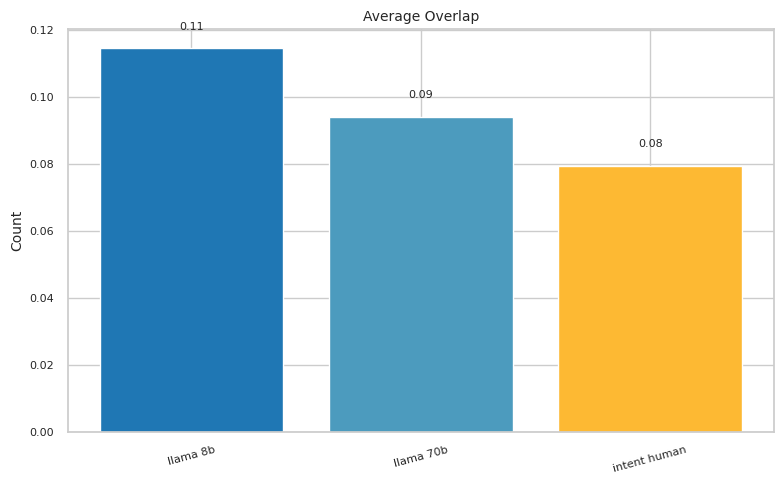

In [13]:
import matplotlib.pyplot as plt

# 数据
labels = ['llama 8b', 
          'llama 70b',
          'intent human']

def calculate_average_score(score_list):
    scores = [item['score'] for item in score_list]
    return np.mean(scores) if scores else 0

values = [calculate_average_score(parse_predict_llama_8b_average_overlap),
          calculate_average_score(parse_predict_llama_70b_average_overlap),
          calculate_average_score(parse_predict_intent_human_average_overlap)]

# 绘图
fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(labels, values, color=['#1f77b4','#4c9bbe','#fdb933','#fbc02d'])

# 在每个柱子上方显示数值
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.005,
        f'{height:.2f}',
        ha='center',
        va='bottom',
        fontsize=8
    )

ax.set_title('Average Overlap', fontsize=10)
ax.set_ylabel('Count', fontsize=10)

plt.xticks(rotation=15, fontsize=8)
plt.yticks(fontsize=8)

plt.tight_layout()
plt.show()

## Explore 

In [24]:
def get_score_with_env(countries, prediction):
    reward_result = get_reward_score(prediction['rewards'])
    score_dict = {}
    score_dict['env'] = prediction['env_uuid']
    score_dict['countries'] = countries
    for c in countries:
        score_dict[f"{c}_taskeval_score"] = prediction[c][c.upper()][1]
        try:
            score_dict[f"{c}_negoeval_score"] = reward_result[c][1]
        except:
            return None
    return score_dict

def get_score_with_env_actual(countries, record):

    score_dict = {}
    
    # 1. env
    score_dict['env'] = record.get('env_uuid', None)
    
    # 2. 当前记录里实际出现了哪些国家
    score_dict['countries'] = countries
    
    # 3. negoeval 来源
    # 注意：negoeval 数据在 'evaluation' 字段中
    evaluation_result = record.get('evaluation', {})

    for c in countries:
        # === (1) taskeval_score ===
        #    在原始数据里形如 record['Austria']['AUSTRIA'] = ['AUSTRIA', -0.0369]
        try:
            score_dict[f"{c}_taskeval_score"] = record[c][c.upper()][1]
        except (KeyError, IndexError, TypeError):
            score_dict[f"{c}_taskeval_score"] = None

        # === (2) negoeval_score ===
        #    原始数据: evaluation_result['AUSTRIA'] = {
        #        'overall_score': 5.0,
        #        'detailed_scores': {'ethos':5.0, 'logos':4.0, 'pathos':6.0}
        #    }
        #    注意：evaluation_result 中的键是大写的国家名
        nego_info = evaluation_result.get(c.upper())
        if nego_info:
            # 拿到 overall_score
            overall_score = nego_info.get('overall_score', None)
            # 拿到 detailed_scores
            ds = nego_info.get('detailed_scores', {})
            
            # 构造新字典
            flattened_dict = {
                'overall_score': overall_score,
                'ethos': ds.get('ethos', None),
                'logos': ds.get('logos', None),
                'pathos': ds.get('pathos', None),
                'goal': ds.get('goal', None)
            }
            score_dict[f"{c}_negoeval_score"] = flattened_dict
        else:
            score_dict[f"{c}_negoeval_score"] = None

    return score_dict

def get_reward_score(rewards):
    result = {}
    for line in rewards.strip().splitlines():
        if not line.strip():
            continue
        key, value_str = line.split(":", 1)
        key = key.strip()
        result[key] = ast.literal_eval(value_str.strip())
    return result

def get_score_dict_from_dialogue(dialogue):
    not_found_count = 0
    score_list = []
    for a in dialogue:
        if a['intent_dialogue'] == "":
            continue
        country_keys = [k for k in a.keys() if k in countries_list]       
        valid_countries = []
        for country in country_keys:
            predict_key = f"{country}_original_predict"
            if predict_key in a and a[predict_key] != "":
                valid_countries.append(country)
            else:
                continue
        
        # 如果没有有效的国家，则跳过此条记录
        if len(valid_countries) != 2:
            continue
        
        keys = []
        for vkeys in a.keys():
            if vkeys in countries_list:
                keys.append(vkeys)
        env_score = get_score_with_env(keys, a)
        if env_score is not None:
            score_list.append(env_score)
        else:
            not_found_count += 1
            continue
    print(f"not found count: {not_found_count}")
    return score_list

def get_score_dict_from_dialogue_actual(dialogue, countries_list):
    """
    批量处理整个 dialogue (即每行 JSON 组成的列表)
    并返回包含评分信息的列表。
    """
    not_found_count = 0
    empty_predict_count = 0
    score_list = []
    
    for item in dialogue:
        # 根据需要过滤 intent_dialogue 为空的情况
        if not item.get('intent_dialogue'):
            continue
        
        # 找出该条中实际有哪些国家
        keys = [k for k in item.keys() if k in countries_list]
        
        # 过滤掉 '{country}_original_predict' 为空的情况
        valid_countries = []
        for country in keys:
            predict_key = f"{country}_original_predict"
            if predict_key in item and item[predict_key] != "":
                valid_countries.append(country)
            else:
                empty_predict_count += 1
        
        # 如果没有有效的国家，则跳过此条记录
        if valid_countries == []:
            continue
        
        # 获取评分
        env_score = get_score_with_env_actual(valid_countries, item)
        if env_score is not None:
            score_list.append(env_score)
        else:
            not_found_count += 1

    print(f"Not found count: {not_found_count}")
    print(f"Empty predict count: {empty_predict_count}")
    return score_list

In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

def flatten_data(data_list):

    rows = []
    for entry in data_list:
        env_value = entry.get('env')
        for country in entry.get('countries', []):
            row = {
                'env': env_value,
                'country': country
            }
            taskeval_key = f'{country}_taskeval_score'
            negoeval_key = f'{country}_negoeval_score'
            if taskeval_key in entry:
                row['taskeval_score'] = entry[taskeval_key]
            else:
                row['taskeval_score'] = np.nan
            
            if negoeval_key in entry:
                row['ethos'] = entry[negoeval_key].get('ethos', np.nan)
                row['logos'] = entry[negoeval_key].get('logos', np.nan)
                row['pathos'] = entry[negoeval_key].get('pathos', np.nan)
                row['goal'] = entry[negoeval_key].get('goal', np.nan)
                row['overall_score'] = entry[negoeval_key].get('overall_score', np.nan)
            else:
                row['ethos'] = np.nan
                row['logos'] = np.nan
                row['pathos'] = np.nan
                row['goal'] = np.nan
                row['overall_score'] = np.nan
            
            rows.append(row)
    
    df = pd.DataFrame(rows)
    return df

def preprocess_and_correlate(df, scale_method='standard'):

    numeric_cols = ['taskeval_score', 'ethos', 'logos', 'pathos', 'goal', 'overall_score']
    
    df_clean = df.dropna(subset=numeric_cols).copy()
    
    if scale_method == 'standard':
        scaler = StandardScaler()
    elif scale_method == 'minmax':
        from sklearn.preprocessing import MinMaxScaler
        scaler = MinMaxScaler()
    else:
        raise ValueError("scale_method only support 'standard' or 'minmax'")
    
    df_clean[numeric_cols] = scaler.fit_transform(df_clean[numeric_cols])
    corr_matrix = df_clean[numeric_cols].corr(method='pearson')
    return corr_matrix, df_clean

def plot_correlation_matrix(corr_df, title="Correlation Matrix"):

    plt.figure(figsize=(6, 5))
    im = plt.imshow(corr_df, cmap='coolwarm', vmin=-1, vmax=1)
    plt.title(title)
    plt.colorbar(im, fraction=0.046, pad=0.04)
    
    ticks = np.arange(len(corr_df.columns))
    plt.xticks(ticks, corr_df.columns, rotation=45, ha="right")
    plt.yticks(ticks, corr_df.columns)
    
    for i in range(len(corr_df.columns)):
        for j in range(len(corr_df.columns)):
            plt.text(j, i, f"{corr_df.iloc[i, j]:.2f}",
                     ha="center", va="center", color="black")
    
    plt.grid(False)  # Disable grid lines
    plt.tight_layout()
    plt.show()

def plot(data_list, model):
    
    df = flatten_data(data_list)

    corr_matrix, df_clean = preprocess_and_correlate(df, scale_method='minmax')

    # print("Correlation Matrix:")
    # print(corr_matrix, "\n")

    plot_correlation_matrix(corr_matrix, title=f"{model.capitalize()} With Backfilling Correlation Matrix (Standard Scaled)")

In [25]:
llama_8b_score = get_score_dict_from_dialogue(llama_8b)
llama_70b_score = get_score_dict_from_dialogue(llama_70b)
intent_human_score = get_score_dict_from_dialogue_actual(intent_human_dialogue, countries_list)

not found count: 0
not found count: 0
Not found count: 0
Empty predict count: 0


In [29]:
llama_8b_score = [i for i in llama_8b_score if i['env'] in match_env_ids]
llama_70b_score = [i for i in llama_70b_score if i['env'] in match_env_ids]
intent_human_score = [i for i in intent_human_score if i['env'] in match_env_ids]

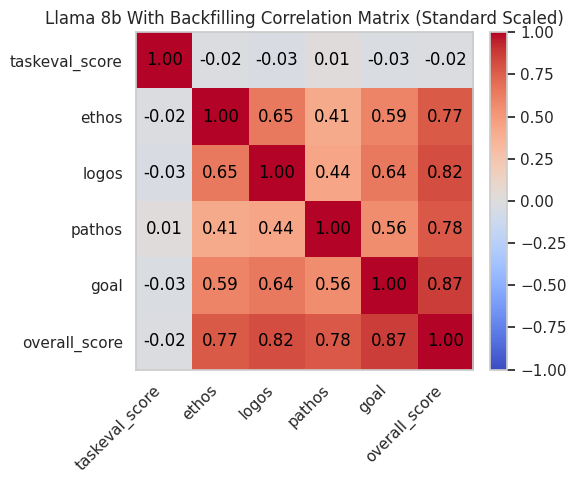

In [30]:
plot(llama_8b_score, "Llama 8b")

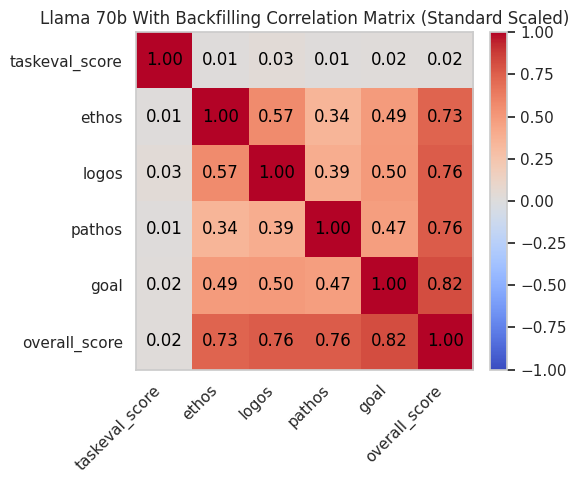

In [31]:
plot(llama_70b_score, "Llama 70b")

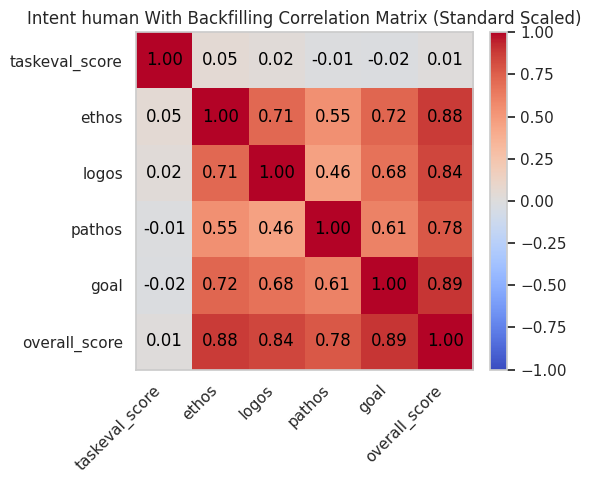

In [32]:
plot(intent_human_score, "Intent Human")

## TaskEval Distribution

In [55]:
def get_whole_score_dict(intent_score):
    result_list = []

    for item in intent_score:
        negoeval_scores = {k: v for k, v in item.items() if k.endswith('_negoeval_score')}
        taskeval_score = {k.split('_')[-2]: v for k, v in item.items() if k.endswith('_taskeval_score')}
        result_dict = {'env': item['env']}
        for k, v in negoeval_scores.items():
            for sub_key, sub_value in v.items():
                result_dict[f"{sub_key}"] = sub_value
        result_dict.update(taskeval_score)
        result_list.append(result_dict)
    return result_list

In [56]:
intent_8b_whole_score_list = get_whole_score_dict(llama_8b_score)
intent_70b_whole_score_list = get_whole_score_dict(llama_70b_score)
intent_human_whole_score_list = get_whole_score_dict(intent_human_score)

In [64]:
actual_score_dict = [i for i in actual_score_dict if i['env'] in match_env_ids]

/tmp/ipykernel_1706671/1703087905.py:17: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data1, shade=True, color='skyblue', alpha=0.8, linewidth=2, label='Llama3 8B')
/tmp/ipykernel_1706671/1703087905.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data2, shade=True, color='green', alpha=0.5, linewidth=2, label='Llama3 70B')
/tmp/ipykernel_1706671/1703087905.py:19: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(data3, shade=True, color='red', alpha=0.3, linewidth=2, label='Intent Human')
/tmp/ipykernel_1706671/1703087905.py:20: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This wi

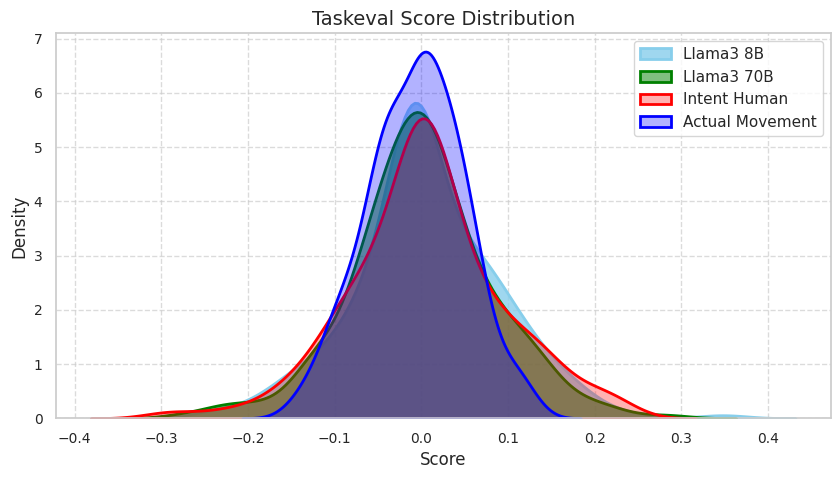

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# TODO: add comparison between human and actual movement
data1 = [d['taskeval'] for d in intent_8b_whole_score_list]
data2 = [d['taskeval'] for d in intent_70b_whole_score_list]
data3 = [d['taskeval'] for d in intent_human_whole_score_list]
data4 = [d['scores'] for d in actual_score_dict]

sns.set(style="whitegrid")

plt.figure(figsize=(10, 5))

labels = ['Llama3 8B', 'Llama3 70B', 'Intent Human']

sns.kdeplot(data1, shade=True, color='skyblue', alpha=0.8, linewidth=2, label='Llama3 8B')
sns.kdeplot(data2, shade=True, color='green', alpha=0.5, linewidth=2, label='Llama3 70B')
sns.kdeplot(data3, shade=True, color='red', alpha=0.3, linewidth=2, label='Intent Human')
sns.kdeplot(data4, shade=True, color='blue', alpha=0.3, linewidth=2, label='Actual Movement')

plt.title('Taskeval Score Distribution', fontsize=14)
plt.xlabel('Score', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.xticks(fontsize=10)
plt.yticks(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()


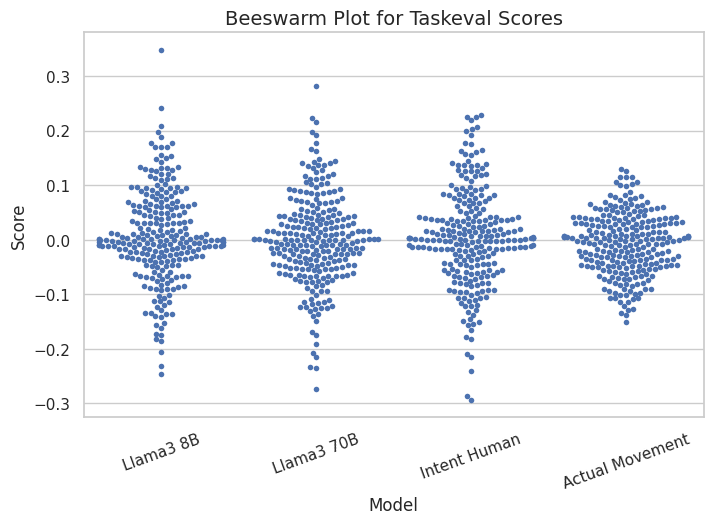

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 假设你已有以下四组数据：
# data1, data2, data3, data4

# 为便于可视化，先构造一个 DataFrame
labels = ['Llama3 8B', 'Llama3 70B', 'Intent Human', 'Actual Movement']
all_data = [data1, data2, data3, data4]

df_bee = pd.DataFrame({
    'score': np.concatenate(all_data),
    'model': np.repeat(labels, [len(d) for d in all_data])
})

plt.figure(figsize=(8, 5))
sns.swarmplot(x='model', y='score', data=df_bee, size=4)
plt.title('Beeswarm Plot for Taskeval Scores', fontsize=14)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.xticks(rotation=20)  # 如果标签较长，可以倾斜一点
plt.show()


/home/wenkail/miniconda3/envs/sotopia/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/home/wenkail/miniconda3/envs/sotopia/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/home/wenkail/miniconda3/envs/sotopia/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  func(*plot_args, **plot_kwargs)
/home/wenkail/miniconda3/envs/sotopia/lib/python3.11/site-packages/seaborn/axisgrid.py:854: FutureWarning: 

`shade` is now deprecated in favor of `fill`;

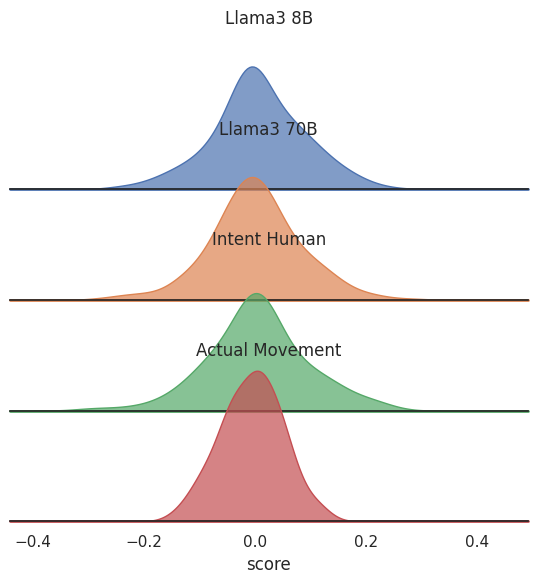

In [71]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 同样先构造 DataFrame
labels = ['Llama3 8B', 'Llama3 70B', 'Intent Human', 'Actual Movement']
all_data = [data1, data2, data3, data4]

df_ridge = pd.DataFrame({
    'score': np.concatenate(all_data),
    'model': np.repeat(labels, [len(d) for d in all_data])
})

# 设置 Seaborn 的主题
sns.set(style="white", rc={"axes.facecolor": (0, 0, 0, 0)})

# 建立 FacetGrid，按 model 分面
g = sns.FacetGrid(df_ridge, row='model', hue='model', aspect=4, height=1.5)
# 每一个子图都画核密度曲线
g.map(sns.kdeplot, 'score', shade=True, alpha=0.7, bw_adjust=1.2)
# 在 y=0 的地方加一条基准线
g.map(plt.axhline, y=0, lw=2, clip_on=False)

# 调整每个子图的样式
g.set_titles(row_template="{row_name}")   # 分面标题为模型名称
g.set(yticks=[], ylabel=None)            # 隐藏 y 轴刻度
g.despine(left=True)                     # 去掉左侧轴线，保持“山峦叠起”的效果

plt.subplots_adjust(hspace=-0.3)         # 让分面之间有一定重叠
plt.show()


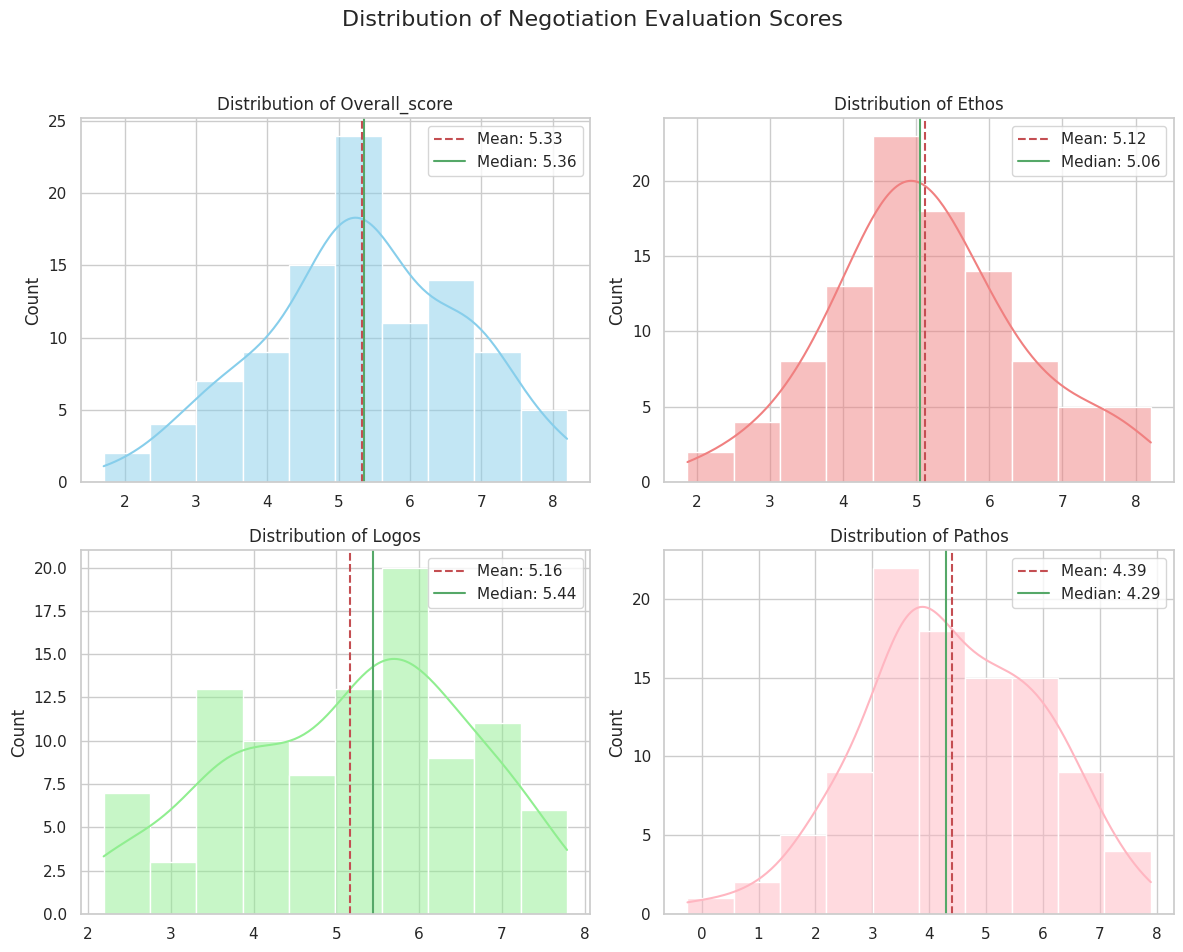

In [69]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Sample data for demonstration
overall_scores = np.random.normal(loc=5.2, scale=1.5, size=100)
ethos_scores = np.random.normal(loc=5.37, scale=1.2, size=100)
logos_scores = np.random.normal(loc=5.18, scale=1.3, size=100)
pathos_scores = np.random.normal(loc=4.49, scale=1.4, size=100)

# Set up the matplotlib figure
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle('Distribution of Negotiation Evaluation Scores', fontsize=16)

# Plot Overall Score
sns.histplot(overall_scores, bins=10, kde=True, ax=axes[0, 0], color='skyblue')
axes[0, 0].set_title('Distribution of Overall_score')
axes[0, 0].axvline(np.mean(overall_scores), color='r', linestyle='--', label=f'Mean: {np.mean(overall_scores):.2f}')
axes[0, 0].axvline(np.median(overall_scores), color='g', linestyle='-', label=f'Median: {np.median(overall_scores):.2f}')
axes[0, 0].legend()

# Plot Ethos Score
sns.histplot(ethos_scores, bins=10, kde=True, ax=axes[0, 1], color='lightcoral')
axes[0, 1].set_title('Distribution of Ethos')
axes[0, 1].axvline(np.mean(ethos_scores), color='r', linestyle='--', label=f'Mean: {np.mean(ethos_scores):.2f}')
axes[0, 1].axvline(np.median(ethos_scores), color='g', linestyle='-', label=f'Median: {np.median(ethos_scores):.2f}')
axes[0, 1].legend()

# Plot Logos Score
sns.histplot(logos_scores, bins=10, kde=True, ax=axes[1, 0], color='lightgreen')
axes[1, 0].set_title('Distribution of Logos')
axes[1, 0].axvline(np.mean(logos_scores), color='r', linestyle='--', label=f'Mean: {np.mean(logos_scores):.2f}')
axes[1, 0].axvline(np.median(logos_scores), color='g', linestyle='-', label=f'Median: {np.median(logos_scores):.2f}')
axes[1, 0].legend()

# Plot Pathos Score
sns.histplot(pathos_scores, bins=10, kde=True, ax=axes[1, 1], color='lightpink')
axes[1, 1].set_title('Distribution of Pathos')
axes[1, 1].axvline(np.mean(pathos_scores), color='r', linestyle='--', label=f'Mean: {np.mean(pathos_scores):.2f}')
axes[1, 1].axvline(np.median(pathos_scores), color='g', linestyle='-', label=f'Median: {np.median(pathos_scores):.2f}')
axes[1, 1].legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()
